# MODELO CHURN - CLIENTES - SOPORTE

## HIPÓTESIS 

H1: Los clientes con un mayor número de interacciones con soporte presentan una mayor probabilidad de churn.

H2: LEl churn presenta diferencias según el tipo de zona geográfica del cliente.

H3: Los clientes de zonas rurales presentan una mayor probabilidad de churn que los clientes de zonas urbanas.

H4: Los clientes con planes de prepago presentan una mayor probabilidad de churn que los clientes con planes premium.

H5: Los clientes que contactan con soporte por incidencias relacionadas con cobertura o calidad de señal presentan una mayor probabilidad de churn.

In [2]:
import warnings

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from scipy import stats

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')

sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.figsize'] = (10, 6)

In [55]:
df_churn= pd.read_csv(r"C:\Users\ancar\Documents\Prácticas\UCV-Churn\data\raw\churn_target.csv")
df_churn

,cliente_id,fecha,churn
0,C000001,2023-01-01,0
1,C000001,2023-02-01,0
2,C000001,2023-03-01,0
3,C000001,2023-04-01,0
4,C000001,2023-05-01,0
...,...,...,...
321982,C010000,2025-08-01,0
321983,C010000,2025-09-01,0
321984,C010000,2025-10-01,0
321985,C010000,2025-11-01,0


In [4]:
df_clientes= pd.read_csv(r"C:\Users\ancar\Documents\Prácticas\UCV-Churn\data\raw\clientes.csv")
df_clientes.head()

,cliente_id,zona_id,region,tipo_zona,poblacion_zona,edad,sexo,estado_civil,num_lineas,tipo_plan,tipo_dispositivo,ingreso_estimado,antiguedad_meses,descuento_activo
0,C000001,Z26,Oeste,urbana_premium,107159,18.00,M,Soltero/a,2,Prepago,Gama alta,"4,335.00",72.00,0
1,C000002,Z15,Oeste,suburbana,62939,54.00,M,Casado/a,2,Premium,Gama media,"4,609.00",35.00,1
2,C000003,Z27,Norte,suburbana,42704,54.00,M,Casado/a,3,Prepago,Gama baja,"1,836.00",11.00,0
3,C000004,Z22,Este,suburbana,53534,34.00,M,Soltero/a,1,Prepago,Gama media,"2,318.00",13.00,0
4,C000005,Z04,Centro,suburbana,55457,46.00,F,Soltero/a,2,Contrato,Gama media,"2,184.00",21.00,0


In [5]:
df_soporte= pd.read_csv(r"C:\Users\ancar\Documents\Prácticas\UCV-Churn\data\raw\interacciones_soporte.csv")
df_soporte.head()

,interaccion_id,cliente_id,fecha_evento,mes,canal,motivo,duracion_min,resuelto,satisfaccion_post,stress_calidad_lag,incidencia_masiva_lag,impago_mes,dias_retraso_mes
0,I923052492930,C000001,2023-02-07,2023-02-01,telefono,Facturación,9.50,0,4.00,0.41,0,0,0
1,I692361171059,C000001,2023-04-20,2023-04-01,app_chat,Facturación,3.90,1,4.00,0.43,0,0,0
2,I354109146175,C000001,2023-04-27,2023-04-01,app_chat,Baja / portabilidad,2.80,1,5.00,0.43,0,0,0
3,I986032353420,C000001,2023-05-04,2023-05-01,telefono,Consulta general,8.40,1,3.00,0.45,0,0,0
4,I553023863181,C000001,2023-06-26,2023-06-01,telefono,Impago / pago,4.50,1,4.00,0.39,0,0,0


In [6]:
df_churn.isnull().sum()

cliente_id    0
fecha         0
churn         0
dtype: int64

In [61]:
df_churn['churn'].value_counts()

churn
0    319987
1      2000
Name: count, dtype: int64

In [7]:
df_churn.duplicated().sum()

np.int64(0)

### ELIMINACIÓN DUPLICADOS CLIENTES

In [8]:
df_clientes.duplicated().sum()

np.int64(150)

In [9]:
df_clientes['cliente_id'].duplicated().sum()

np.int64(150)

In [10]:
df_clientes[
    df_clientes['cliente_id'].duplicated(keep=False)
].sort_values('cliente_id')

,cliente_id,zona_id,region,tipo_zona,poblacion_zona,edad,sexo,estado_civil,num_lineas,tipo_plan,tipo_dispositivo,ingreso_estimado,antiguedad_meses,descuento_activo
5,C000006,Z30,Centro,suburbana,33966,37.00,M,Casado/a,3,Prepago,Gama media,"2,411.00",86.00,0
10033,C000006,Z30,Centro,suburbana,33966,37.00,M,Casado/a,3,Prepago,Gama media,"2,411.00",86.00,0
87,C000088,Z16,Este,urbana_premium,72683,18.00,M,Soltero/a,3,Contrato,Gama media,"2,492.00",25.00,0
10130,C000088,Z16,Este,urbana_premium,72683,18.00,M,Soltero/a,3,Contrato,Gama media,"2,492.00",25.00,0
100,C000101,Z28,Sur,urbana_premium,64486,22.00,M,Soltero/a,2,Premium,Gama alta,"4,181.00",NaN,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9856,C009857,Z21,Centro,rural,19103,52.00,F,Casado/a,2,Prepago,Gama baja,"2,553.00",41.00,0
10032,C009898,Z26,Oeste,urbana_premium,107159,26.00,?,Soltero/a,3,Premium,Gama media,"4,275.00",7.00,1
9897,C009898,Z26,Oeste,urbana_premium,107159,26.00,?,Soltero/a,3,Premium,Gama media,"4,275.00",7.00,1
10062,C009950,Z17,Sur,suburbana,56619,37.00,X,Soltero/a,1,Premium,Gama media,"3,569.00",65.00,1


In [11]:
df_clientes = df_clientes.drop_duplicates()

In [12]:
df_clientes.isnull().sum()

cliente_id            0
zona_id               0
region                0
tipo_zona             0
poblacion_zona        0
edad                300
sexo                 45
estado_civil         77
num_lineas            0
tipo_plan             0
tipo_dispositivo      0
ingreso_estimado    300
antiguedad_meses    300
descuento_activo      0
dtype: int64

### ELIMINACIÓN NULOS CSV CLIENTES

In [13]:
df_clientes.describe()

,poblacion_zona,edad,num_lineas,ingreso_estimado,antiguedad_meses,descuento_activo
count,"10,000.00","9,700.00","10,000.00","9,700.00","9,700.00","10,000.00"
mean,"60,004.60",39.34,2.31,"3,476.79",32.55,0.26
std,"28,724.37",11.97,1.02,"1,411.89",22.53,0.44
min,"11,707.00",18.00,1.00,900.00,-110.00,0.00
25%,"41,163.00",31.00,2.00,"2,466.00",18.00,0.00
50%,"56,342.00",39.00,2.00,"3,219.00",29.00,0.00
75%,"72,683.00",47.00,3.00,"4,194.25",44.00,1.00
max,"107,159.00",80.00,5.00,"12,000.00",120.00,1.00


In [14]:
df_clientes['edad'] = df_clientes['edad'].fillna(
    df_clientes['edad'].median()
)

In [15]:
df_clientes['ingreso_estimado'] = df_clientes['ingreso_estimado'].fillna(
    df_clientes['ingreso_estimado'].median()
)

In [16]:
df_clientes['antiguedad_meses'] = df_clientes['antiguedad_meses'].fillna(
    df_clientes['antiguedad_meses'].median()
)

In [17]:
df_clientes['sexo'] = df_clientes['sexo'].fillna('Desconocido')

In [18]:
df_clientes['estado_civil'] = df_clientes['estado_civil'].fillna('Desconocido')

In [19]:
df_clientes.isnull().sum()

cliente_id          0
zona_id             0
region              0
tipo_zona           0
poblacion_zona      0
edad                0
sexo                0
estado_civil        0
num_lineas          0
tipo_plan           0
tipo_dispositivo    0
ingreso_estimado    0
antiguedad_meses    0
descuento_activo    0
dtype: int64

In [20]:
df_soporte.duplicated().sum()

np.int64(4558)

In [21]:
duplicados = df_soporte[
    df_soporte['interaccion_id'].duplicated(
        keep=False
    )
]

duplicados.head(20)

,interaccion_id,cliente_id,fecha_evento,mes,canal,motivo,duracion_min,resuelto,satisfaccion_post,stress_calidad_lag,incidencia_masiva_lag,impago_mes,dias_retraso_mes
212,I716491295118,C000007,2023-06-01,2023-06-01,tienda,Consulta general,13.00,0,2.00,0.39,0,0,0
248,I271008632610,C000008,2023-10-04,2023-10-01,telefono,Cambio de plan,4.10,1,5.00,0.41,0,0,0
255,I831660710653,C000008,2024-04-25,2024-04-01,app_chat,Calidad de señal,8.00,1,3.00,0.30,0,0,0
317,I666962040807,C000010,2025-08-20,2025-08-01,telefono,Consulta general,4.90,0,5.00,0.40,0,0,0
326,I721437122731,C000011,2023-04-14,2023-04-01,telefono,Baja / portabilidad,10.80,0,3.00,0.54,0,0,0
444,I747915945768,C000013,2025-06-15,2025-06-01,tienda,Calidad de señal,1.00,1,5.00,0.36,0,0,0
563,I705123563177,C000017,2024-08-25,2024-08-01,tienda,Facturación,2.60,0,3.00,0.48,0,1,41
572,I801443917956,C000018,2023-04-15,2023-04-01,app_chat,Calidad de señal,3.70,1,3.00,0.52,0,0,0
579,I748444381545,C000018,2023-09-16,2023-09-01,telefono,Cobertura / velocidad,1.20,0,2.00,0.54,0,0,0
725,I389032705098,C000023,2023-08-10,2023-08-01,app_chat,Impago / pago,7.30,1,4.00,0.39,0,1,28


In [22]:
df_soporte[
    df_soporte['interaccion_id'] == 'I716491295118'
]

,interaccion_id,cliente_id,fecha_evento,mes,canal,motivo,duracion_min,resuelto,satisfaccion_post,stress_calidad_lag,incidencia_masiva_lag,impago_mes,dias_retraso_mes
212,I716491295118,C000007,2023-06-01,2023-06-01,tienda,Consulta general,13.00,0,2.00,0.39,0,0,0
303947,I716491295118,C000007,2023-06-01,2023-06-01,tienda,Consulta general,13.00,0,2.00,0.39,0,0,0


In [23]:
df_soporte = df_soporte.drop_duplicates()

In [24]:
df_soporte['interaccion_id'].duplicated().sum()

np.int64(0)

### ELIMINAR NULOS DEL CSV DE SOPORTE

In [25]:
df_soporte['interaccion_id'].duplicated().sum()

np.int64(0)

In [26]:
df_soporte.isnull().sum()

interaccion_id              0
cliente_id                  0
fecha_evento                0
mes                         0
canal                       0
motivo                   4558
duracion_min                0
resuelto                    0
satisfaccion_post        4558
stress_calidad_lag          0
incidencia_masiva_lag       0
impago_mes                  0
dias_retraso_mes            0
dtype: int64

### ELIMINACIÓN NULOS DEL CSV DE SOPORTE


In [27]:
df_soporte['motivo'] = df_soporte['motivo'].fillna('Desconocido')

In [28]:
df_soporte['sin_satisfaccion'] = (
    df_soporte['satisfaccion_post']
    .isnull()
    .astype(int)
)

In [29]:
df_soporte['satisfaccion_post'] = (
    df_soporte['satisfaccion_post']
    .fillna(-1)
)

La variable satisfaccion_post presentaba valores faltantes asociados probablemente a clientes que no respondieron la encuesta posterior a la interacción. En lugar de eliminar registros, se decidió conservar la información creando una categoría diferenciada para ausencia de respuesta, evitando así pérdida innecesaria de datos.

In [30]:
df_soporte.isnull().sum()

interaccion_id           0
cliente_id               0
fecha_evento             0
mes                      0
canal                    0
motivo                   0
duracion_min             0
resuelto                 0
satisfaccion_post        0
stress_calidad_lag       0
incidencia_masiva_lag    0
impago_mes               0
dias_retraso_mes         0
sin_satisfaccion         0
dtype: int64

## Granularidad -

 Que representa cada fila del dataset

*Churn*: Clientes/mes

*Cliente*: Cliente

*Soporte*: Cliente/ Interacción con soporte

In [85]:
# Vamos a convertir soporte a clientes-mes

soporte_cliente = (
    df_soporte.groupby('cliente_id')
    .agg({
        'interaccion_id':'count',
        'duracion_min':'mean',
        'resuelto':'mean',
        'satisfaccion_post':'mean'
    })
    .reset_index()
)

In [86]:
soporte_cliente.rename(columns={
    'interaccion_id':'num_interacciones_total',
    'duracion_min':'duracion_media',
    'resuelto':'pct_resuelto',
    'satisfaccion_post':'satisfaccion_media'
}, inplace=True)

In [91]:
soporte_cliente['interacciones_por_mes'] = (
    soporte_cliente['num_interacciones_total']
    / soporte_cliente['antiguedad_meses']
)

In [90]:
soporte_cliente = soporte_cliente.merge(
    df_clientes[
        ['cliente_id', 'antiguedad_meses']
    ],
    on='cliente_id',
    how='left'
)

In [92]:
soporte_cliente[
    'interacciones_por_mes'
] = (
    soporte_cliente[
        'interacciones_por_mes'
    ]
    .replace([np.inf, -np.inf], 0)
    .fillna(0)
)

In [93]:
churn_cliente = (
    df_churn.groupby('cliente_id')['churn']
    .max()
    .reset_index()
)

In [94]:
df_modelo_final = churn_cliente.merge(
    df_clientes,
    on='cliente_id',
    how='left'
)

In [95]:
df_modelo_final = df_modelo_final.merge(
    soporte_cliente,
    on='cliente_id',
    how='left'
)

In [96]:
cols_soporte = [
    'num_interacciones_total',
    'duracion_media',
    'pct_resuelto',
    'satisfaccion_media',
    'interacciones_por_mes'
]

df_modelo_final[cols_soporte] = (
    df_modelo_final[cols_soporte]
    .fillna(0)
)

In [97]:
df_modelo_final.duplicated().sum()

np.int64(0)

In [98]:
df_modelo_final.isnull().sum()

cliente_id                  0
churn                       0
zona_id                     0
region                      0
tipo_zona                   0
poblacion_zona              0
edad                        0
sexo                        0
estado_civil                0
num_lineas                  0
tipo_plan                   0
tipo_dispositivo            0
ingreso_estimado            0
antiguedad_meses_x          0
descuento_activo            0
num_interacciones_total     0
duracion_media              0
pct_resuelto                0
satisfaccion_media          0
antiguedad_meses_y         27
interacciones_por_mes       0
dtype: int64

In [99]:
df_modelo_final = df_modelo_final.drop(
    columns=['antiguedad_meses_y']
)

In [100]:
df_modelo_final = df_modelo_final.rename(
    columns={
        'antiguedad_meses_x':'antiguedad_meses'
    }
)

In [101]:
df_modelo_final.isnull().sum()

cliente_id                 0
churn                      0
zona_id                    0
region                     0
tipo_zona                  0
poblacion_zona             0
edad                       0
sexo                       0
estado_civil               0
num_lineas                 0
tipo_plan                  0
tipo_dispositivo           0
ingreso_estimado           0
antiguedad_meses           0
descuento_activo           0
num_interacciones_total    0
duracion_media             0
pct_resuelto               0
satisfaccion_media         0
interacciones_por_mes      0
dtype: int64

# VISUALIZACIÓN VARIABLES

H1: Los clientes con un mayor número de interacciones con soporte presentan una mayor probabilidad de churn.

H2: LEl churn presenta diferencias según el tipo de zona geográfica del cliente.

H3: Los clientes de zonas rurales presentan una mayor probabilidad de churn que los clientes de zonas urbanas.

H4: Los clientes con planes de prepago presentan una mayor probabilidad de churn que los clientes con planes premium.

H5: Los clientes que contactan con soporte por incidencias relacionadas con cobertura o calidad de señal presentan una mayor probabilidad de churn.

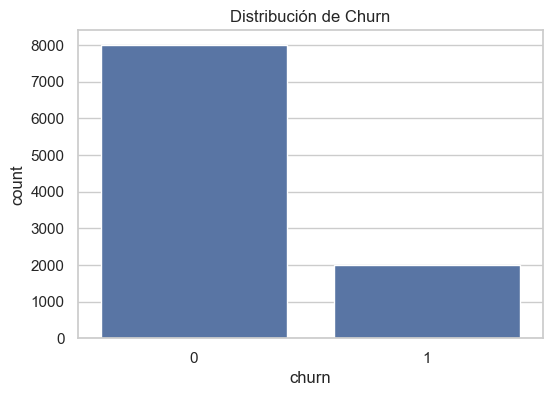

In [102]:


plt.figure(figsize=(6, 4))
sns.countplot(data=df_modelo_final, x='churn')
plt.title('Distribución de Churn')
plt.show()


In [103]:
df_modelo_final.describe()

,churn,poblacion_zona,edad,num_lineas,ingreso_estimado,antiguedad_meses,descuento_activo,num_interacciones_total,duracion_media,pct_resuelto,satisfaccion_media,interacciones_por_mes
count,"10,000.00","10,000.00","10,000.00","10,000.00","10,000.00","10,000.00","10,000.00","10,000.00","10,000.00","10,000.00","10,000.00","10,000.00"
mean,0.20,"60,004.60",39.33,2.31,"3,469.05",32.44,0.26,30.39,6.00,0.58,3.38,1.43
std,0.40,"28,724.37",11.79,1.02,"1,391.25",22.19,0.44,12.51,0.90,0.11,0.31,2.09
min,0.00,"11,707.00",18.00,1.00,900.00,-110.00,0.00,0.00,0.00,0.00,0.00,-16.50
25%,0.00,"41,163.00",31.00,2.00,"2,488.00",18.00,0.00,22.00,5.52,0.51,3.24,0.56
50%,0.00,"56,342.00",39.00,2.00,"3,219.00",29.00,0.00,30.00,6.03,0.58,3.39,0.96
75%,0.00,"72,683.00",47.00,3.00,"4,157.25",44.00,1.00,38.00,6.51,0.65,3.55,1.66
max,1.00,"107,159.00",80.00,5.00,"12,000.00",120.00,1.00,82.00,14.10,1.00,5.00,58.00


In [105]:
df_modelo_final[
    df_modelo_final['antiguedad_meses'] < 0
]

,cliente_id,churn,zona_id,region,tipo_zona,poblacion_zona,edad,sexo,estado_civil,num_lineas,tipo_plan,tipo_dispositivo,ingreso_estimado,antiguedad_meses,descuento_activo,num_interacciones_total,duracion_media,pct_resuelto,satisfaccion_media,interacciones_por_mes
31,C000032,0,Z29,Oeste,urbana_premium,67334,36.00,M,Casado/a,5,Premium,Gama baja,"2,525.00",-87.00,0,32.00,6.15,0.53,3.50,-0.37
142,C000143,0,Z29,Oeste,urbana_premium,67334,28.00,F,Soltero/a,2,Premium,Gama baja,"4,227.00",-48.00,0,19.00,6.09,0.68,3.74,-0.40
156,C000157,0,Z09,Norte,urbana_premium,102625,45.00,F,Soltero/a,3,Premium,Gama alta,"6,397.00",-37.00,1,20.00,6.83,0.55,3.45,-0.54
234,C000235,0,Z29,Oeste,urbana_premium,67334,33.00,F,Soltero/a,2,Prepago,Gama media,"2,426.00",-43.00,0,25.00,4.71,0.56,3.28,-0.58
578,C000579,0,Z27,Norte,suburbana,42704,34.00,M,Soltero/a,2,Prepago,Gama baja,"1,781.00",-18.00,0,48.00,6.20,0.60,3.52,-2.67
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9839,C009840,0,Z29,Oeste,urbana_premium,67334,43.00,F,Casado/a,4,Prepago,Gama alta,"4,631.00",-28.00,0,29.00,7.43,0.62,3.69,-1.04
9901,C009902,0,Z07,Centro,rural,15473,48.00,F,Casado/a,2,Contrato,Gama media,"2,215.00",-17.00,0,34.00,7.04,0.44,3.26,-2.00
9905,C009906,0,Z22,Este,suburbana,53534,56.00,M,Casado/a,2,Premium,Gama alta,"4,210.00",-27.00,0,45.00,5.80,0.51,3.16,-1.67
9909,C009910,0,Z27,Norte,suburbana,42704,61.00,F,Soltero/a,1,Premium,Gama alta,"3,705.00",-44.00,0,34.00,6.88,0.59,3.68,-0.77


In [107]:
df_modelo_final = df_modelo_final[
    df_modelo_final['antiguedad_meses'] >= 0
]

df_modelo_final['interacciones_por_mes'] = (
    df_modelo_final['num_interacciones_total']
    / df_modelo_final['antiguedad_meses']
)

df_modelo_final['interacciones_por_mes'] = (
    df_modelo_final['interacciones_por_mes']
    .replace([np.inf, -np.inf], 0)
    .fillna(0)
)

In [108]:
df_modelo_final.describe()

,churn,poblacion_zona,edad,num_lineas,ingreso_estimado,antiguedad_meses,descuento_activo,num_interacciones_total,duracion_media,pct_resuelto,satisfaccion_media,interacciones_por_mes
count,"9,855.00","9,855.00","9,855.00","9,855.00","9,855.00","9,855.00","9,855.00","9,855.00","9,855.00","9,855.00","9,855.00","9,855.00"
mean,0.20,"60,035.10",39.32,2.30,"3,468.85",33.42,0.26,30.36,6.00,0.58,3.38,1.48
std,0.40,"28,691.34",11.81,1.02,"1,392.56",20.67,0.44,12.50,0.90,0.11,0.31,2.06
min,0.00,"11,707.00",18.00,1.00,900.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,0.00,"41,163.00",31.00,2.00,"2,487.00",18.00,0.00,22.00,5.52,0.51,3.24,0.58
50%,0.00,"56,342.00",39.00,2.00,"3,219.00",29.00,0.00,30.00,6.03,0.58,3.39,0.97
75%,0.00,"72,683.00",47.00,3.00,"4,158.50",44.00,1.00,38.00,6.51,0.65,3.55,1.67
max,1.00,"107,159.00",80.00,5.00,"12,000.00",120.00,1.00,82.00,14.10,1.00,5.00,58.00


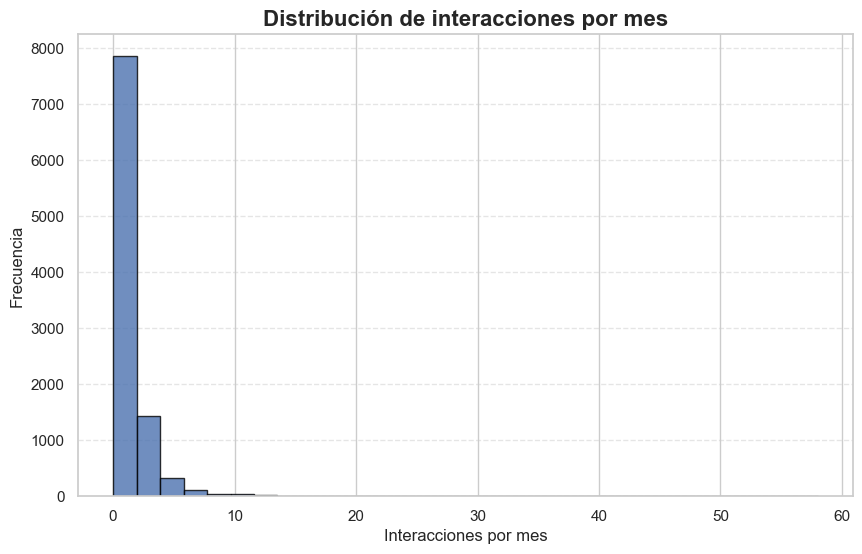

In [109]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.hist(
    df_modelo_final['interacciones_por_mes'],
    bins=30,
    edgecolor='black',
    alpha=0.8)

plt.title(
    'Distribución de interacciones por mes',
    fontsize=16,
    fontweight='bold'
)

plt.xlabel(
    'Interacciones por mes',
    fontsize=12
)

plt.ylabel(
    'Frecuencia',
    fontsize=12
)

plt.grid(
    axis='y',
    linestyle='--',
    alpha=0.5
)

plt.show()

In [110]:
df_modelo_final['tipo_plan'].value_counts()

tipo_plan
Premium     4984
Prepago     2638
Contrato    2233
Name: count, dtype: int64

In [111]:
df_modelo_final['tipo_zona'].value_counts()

tipo_zona
urbana_premium    4420
suburbana         3977
rural             1458
Name: count, dtype: int64

In [ ]:
df_modelo_final['tipo_plan'].value_counts()

Se detectaron registros con valores imposibles en la variable antiguedad_meses (valores negativos). Dado que no tenían interpretación válida desde el punto de vista de negocio, se decidió excluir dichos registros del análisis para evitar distorsiones en las variables derivadas.

En este caso no eliminamos los outliers ya que pueden ser de clientes que lleven mucho tiempo llamando a servicio técnico o hayan tenido muchos problemas

### CONTRASTE HIPÓTESIS
